In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("Cardiotocographic.csv")

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [ ]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [ ]:
# remove spaces
df.columns= df.columns.str.strip()
# handel missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    print(f"\nColumn: {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())
    print("----------------------")


Column: LB
Mean: 133.3435983550352
Median: 133.0
Mode: 133.0
Standard Deviation: 11.214327973675747
----------------------

Column: AC
Mean: 0.0032189782438000465
Median: 0.001668057
Mode: 0.0
Standard Deviation: 0.004370061114881724
----------------------

Column: FM
Mean: 0.009894484174097834
Median: 0.0
Mode: 0.0
Standard Deviation: 0.06753967969018713
----------------------

Column: UC
Mean: 0.004390615424744109
Median: 0.004484305
Mode: 0.0
Standard Deviation: 0.0033404622309868236
----------------------

Column: DL
Mean: 0.0018953447635069313
Median: 0.0
Mode: 0.0
Standard Deviation: 0.003342682284130469
----------------------

Column: DS
Mean: 2.5089835057102835e-06
Median: 0.0
Mode: 0.0
Standard Deviation: 0.00014083438373385573
----------------------

Column: DP
Mean: 0.000175151211746347
Median: 0.0
Mode: 0.0
Standard Deviation: 0.0008356116010872265
----------------------

Column: ASTV
Mean: 46.99598415495999
Median: 49.0
Mode: 65.0
Standard Deviation: 18.813972683314418
--

## Interpretation of Statistical Measures

### LB (Baseline Fetal Heart Rate)
- The mean and median values indicate the average fetal heart rate.
- If mean is close to median, the data is approximately symmetric.
- Variations in values show differences in fetal heart rate among patients.

### AC (Accelerations)
- Higher mean values indicate good fetal response and well-being.
- If mean > median, it suggests some higher acceleration cases.
- Variation shows different fetal activity levels.


### FM (Fetal Movements)
- Higher values indicate active fetal movement (healthy condition).
- Lower values may indicate reduced fetal activity.
- Variability shows inconsistency in fetal movements.


## UC (Uterine Contractions)
- Mean shows average contraction frequency.
- High values may impact fetal heart rate.
- Variation indicates differences in contraction patterns.


### DL, DS, DP (Decelerations)
- Higher values may indicate fetal stress or complications.
- Positive skewness suggests few extreme abnormal cases.
- These features are critical indicators of fetal distress.

### ASTV, ALTV (Abnormal Variability)
- Higher values indicate abnormal fetal heart rate patterns.
- These are strong indicators of possible risk conditions.
- High variation suggests inconsistency in abnormal patterns.


### MSTV, MLTV (Mean Variability)
- These indicate normal variability in fetal heart rate.
- Higher values generally indicate better fetal condition.
- Lower values may indicate reduced adaptability.

## Overall Conclusion
- Accelerations and fetal movements indicate healthy fetal condition.
- Decelerations and abnormal variability indicate possible fetal stress.
- Variability features are key indicators in fetal health analysis.
- The dataset shows variation, which is useful for predictive modeling.

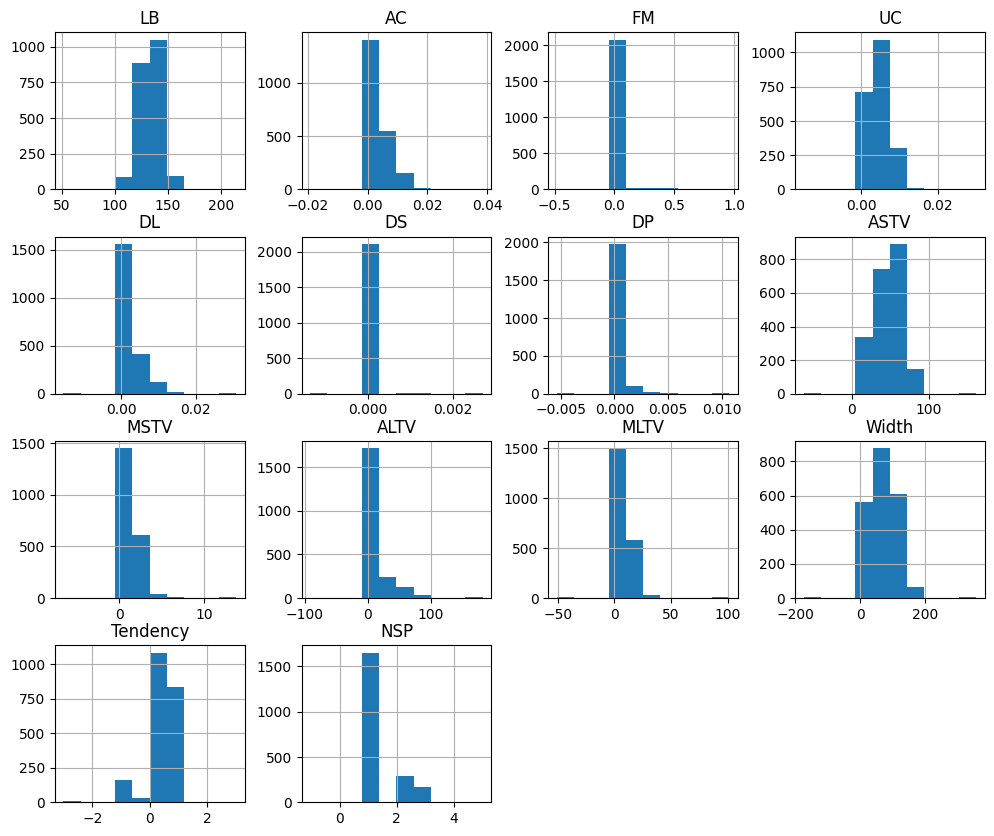

In [ ]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(12,10))
plt.show()

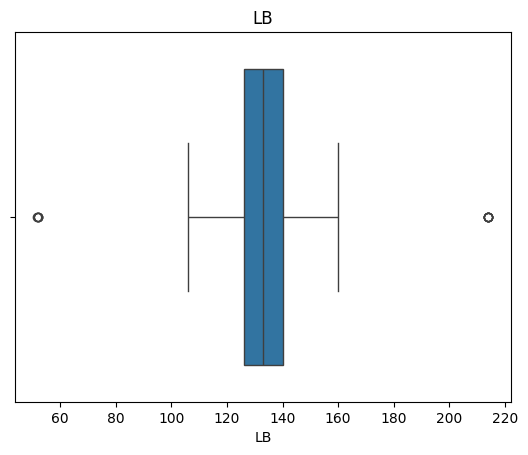

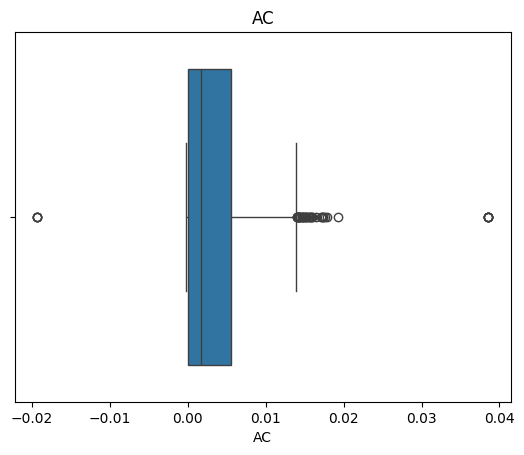

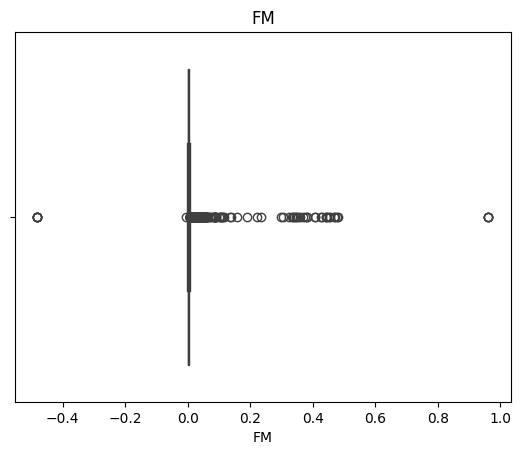

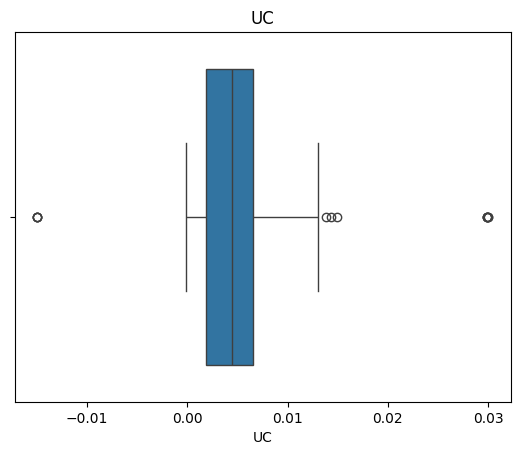

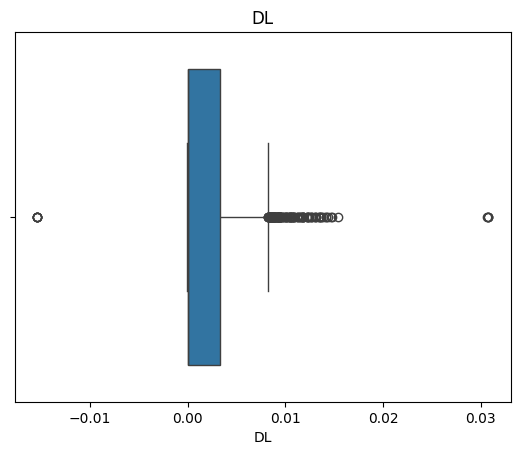

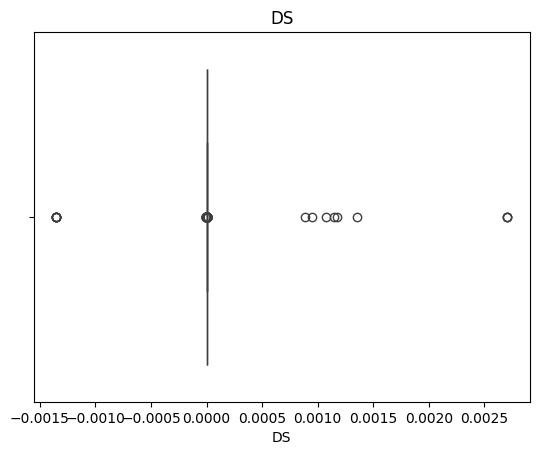

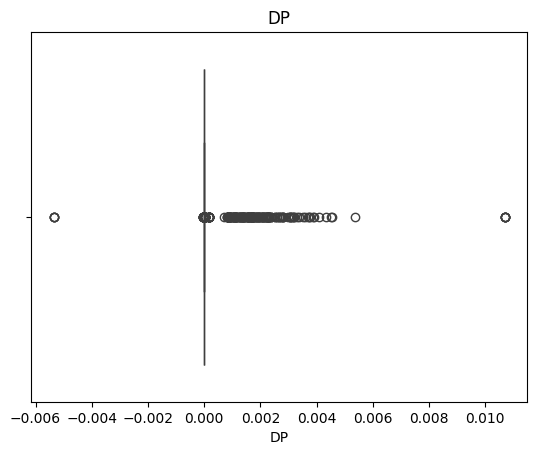

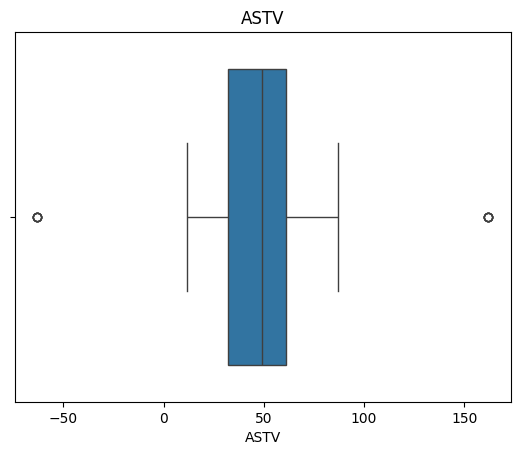

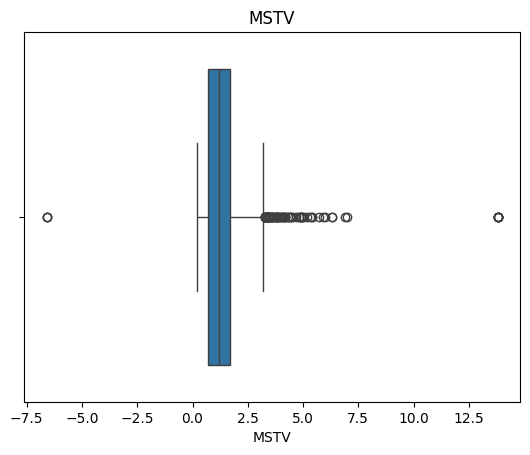

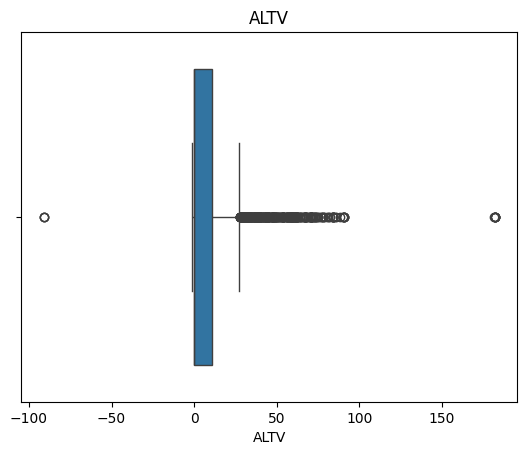

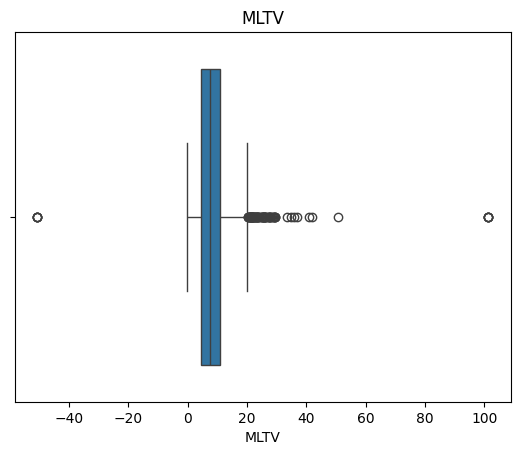

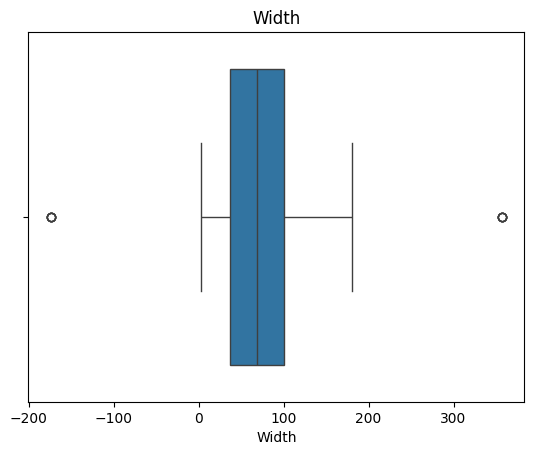

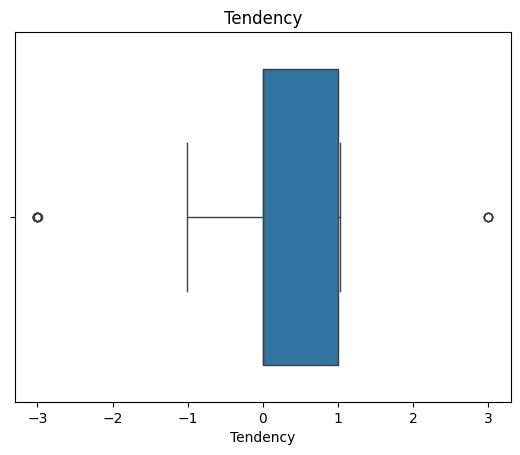

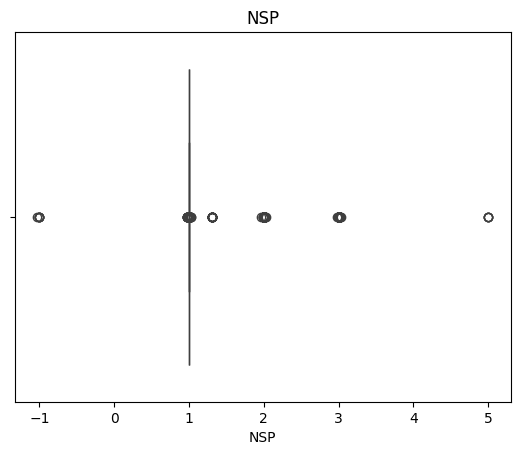

In [ ]:
import seaborn as sns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

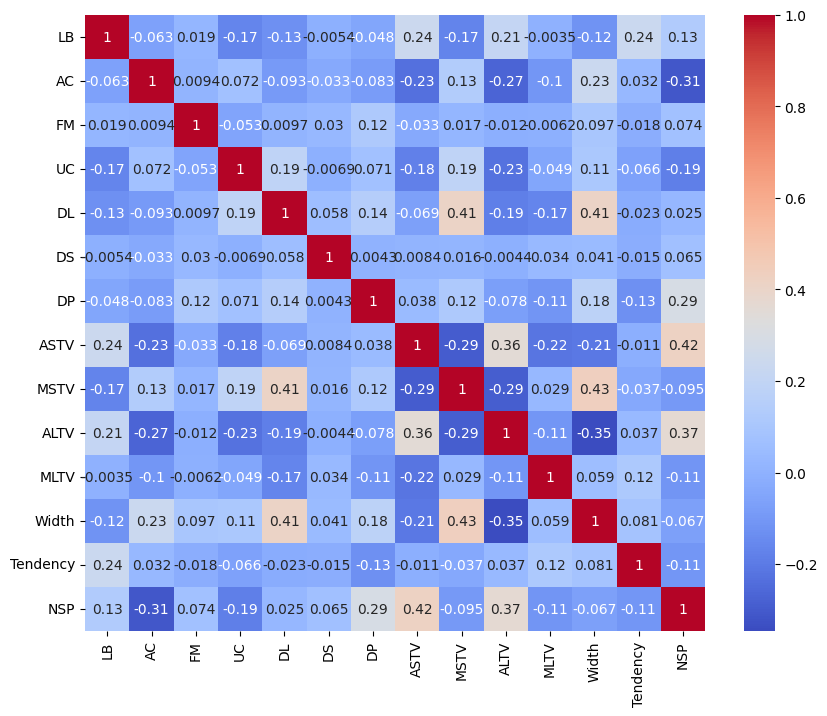

In [ ]:
numeric_df = df.select_dtypes(include='number')
numeric_df = numeric_df.fillna(numeric_df.mean())

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

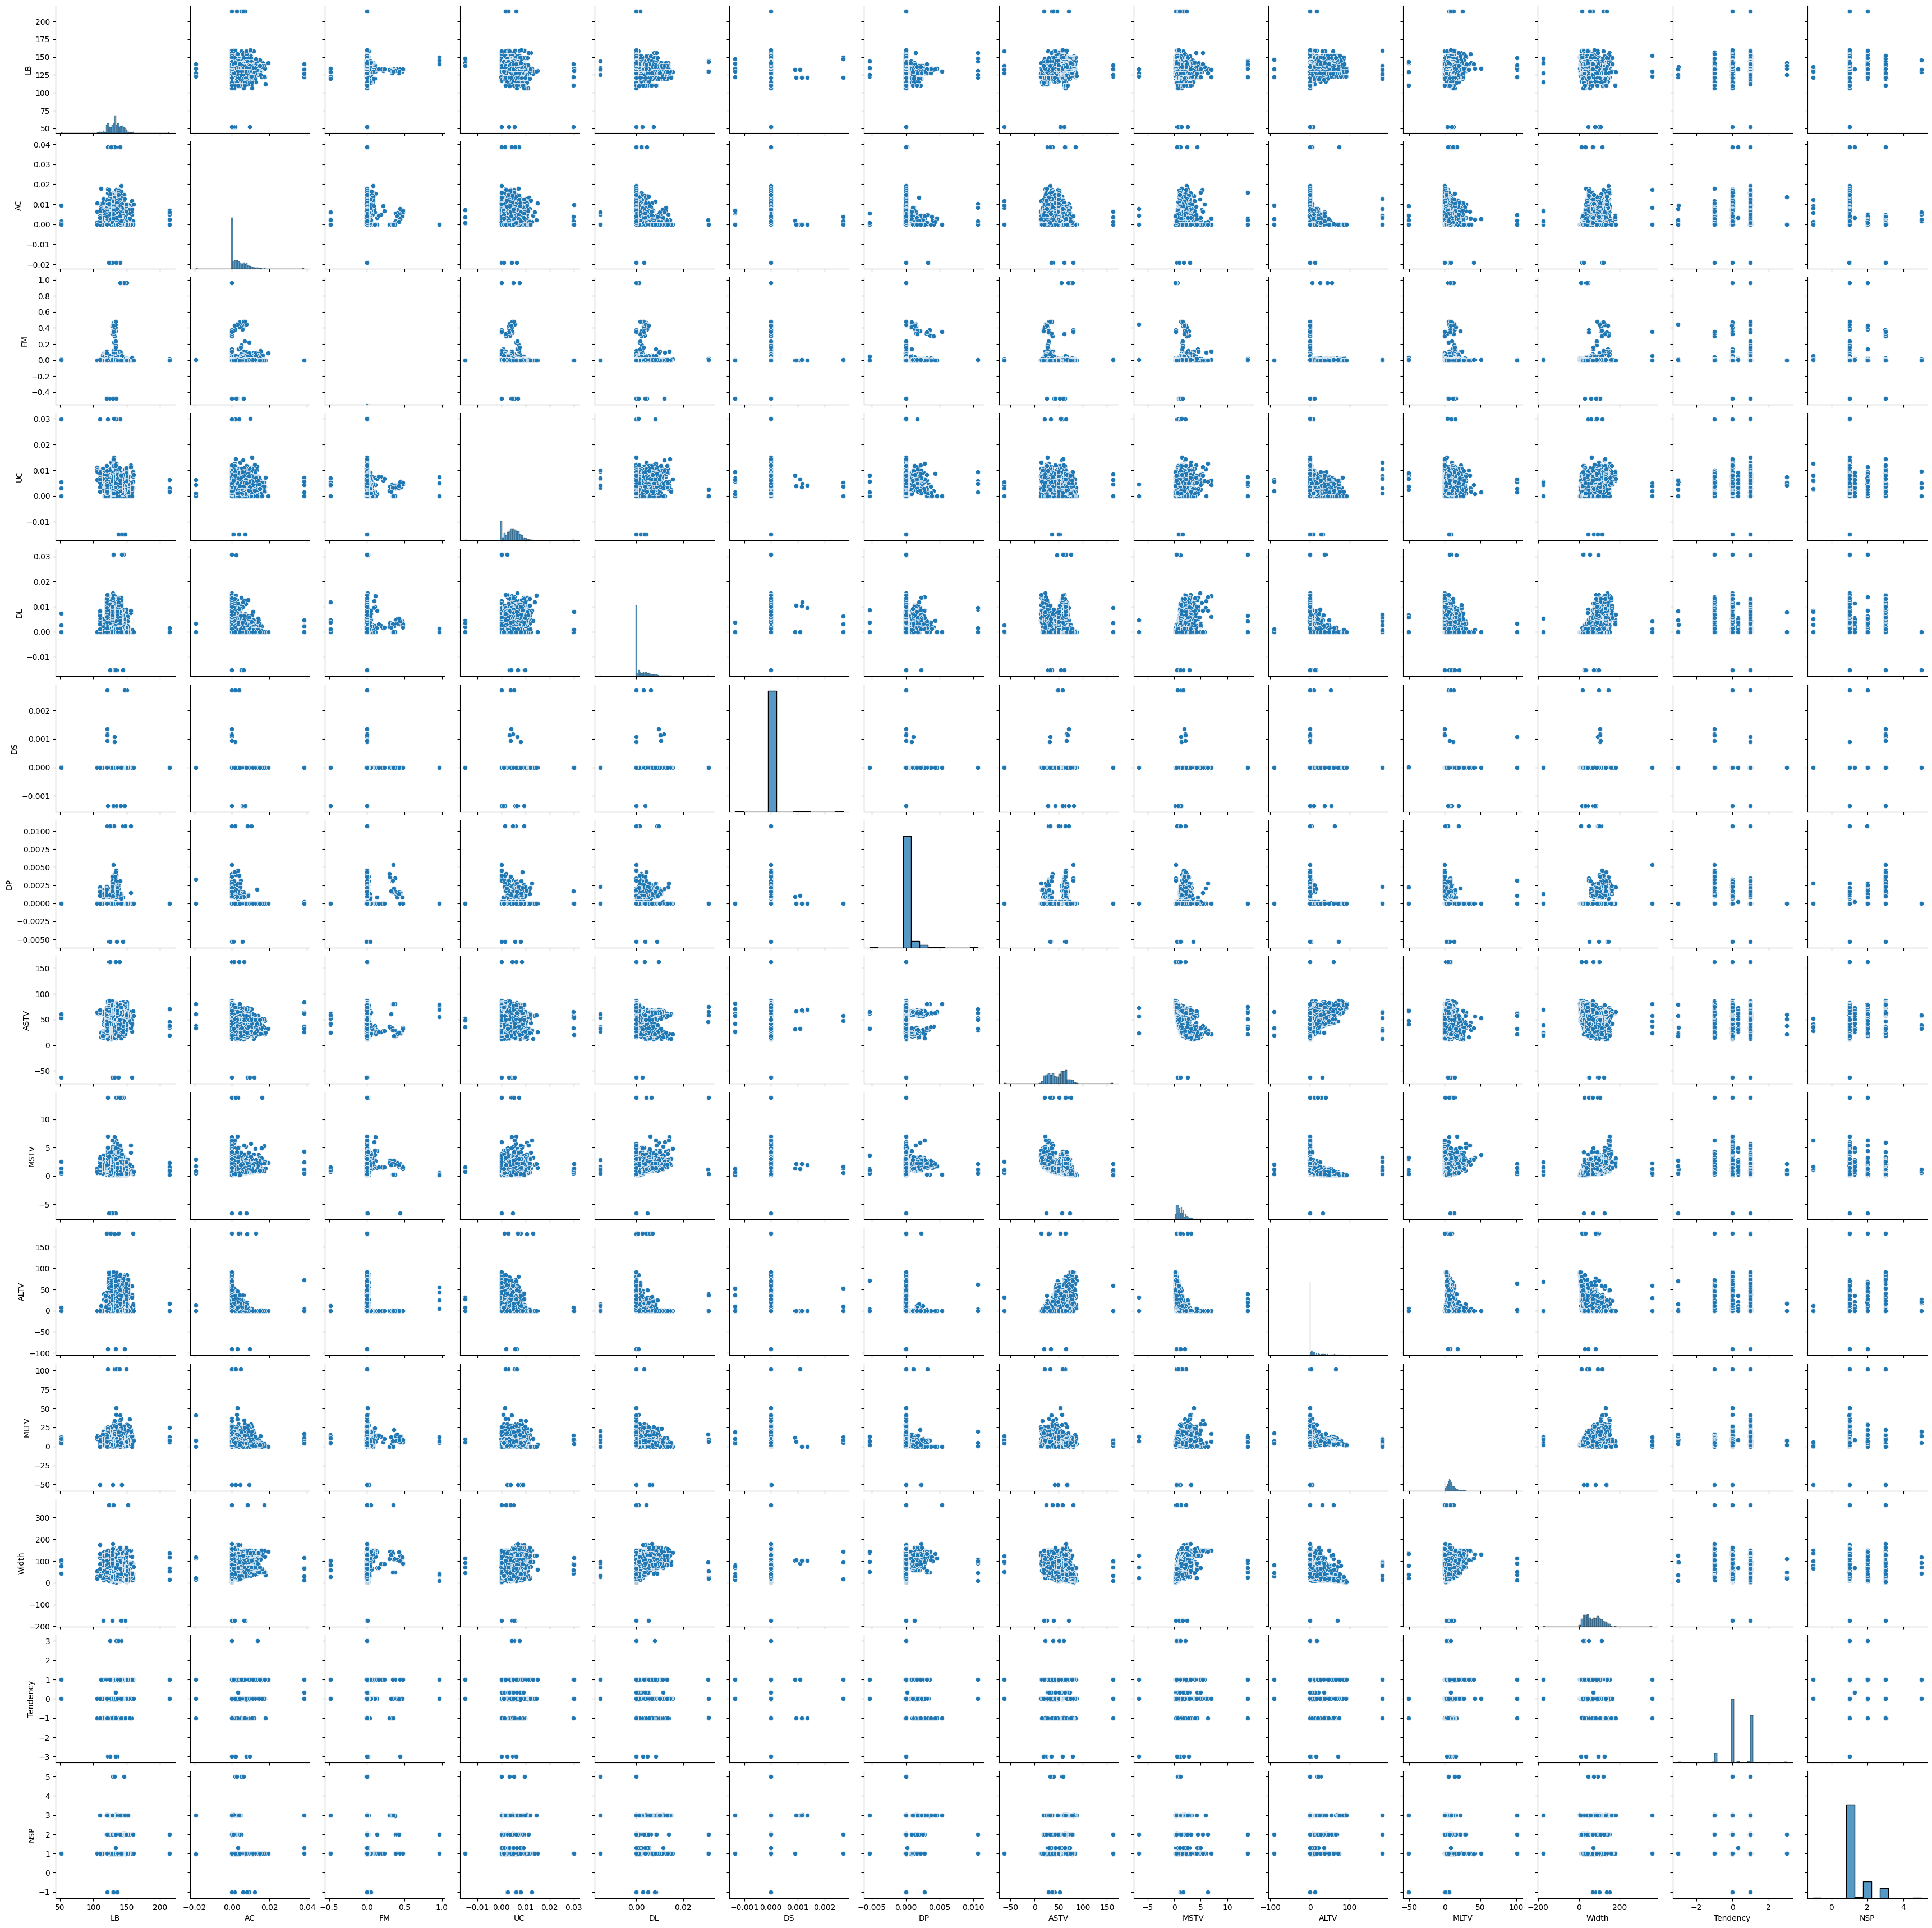

In [ ]:
sns.pairplot(df)
plt.show()